#Predicting Car Prices

The goal is to estimate the price of a car based on various features such as 
the brand, model, year of manufacture, mileage, condition, and more.

Prepared by Kristi Koju
KCE080BCT010

In [24]:
#importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [17]:
df=pd.read_csv(r'C:\Users\krist\Downloads\CarPrice.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [18]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [19]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


EDA task

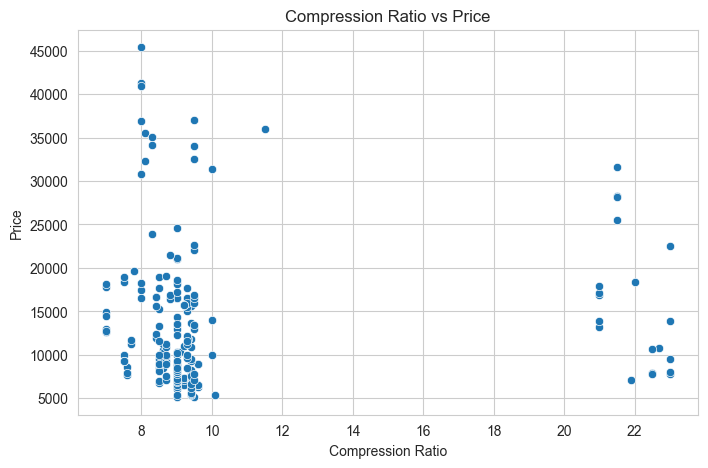

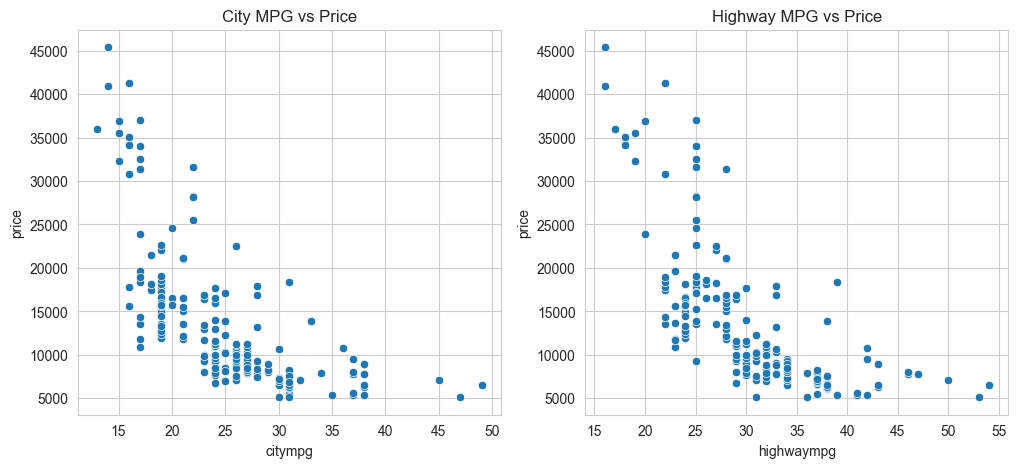

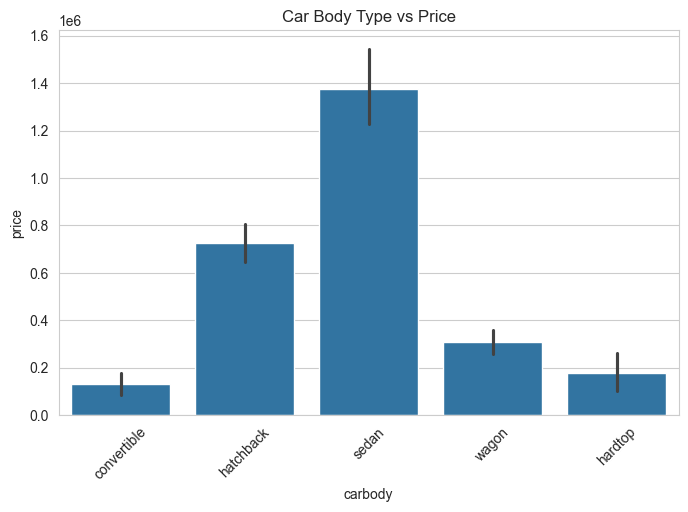

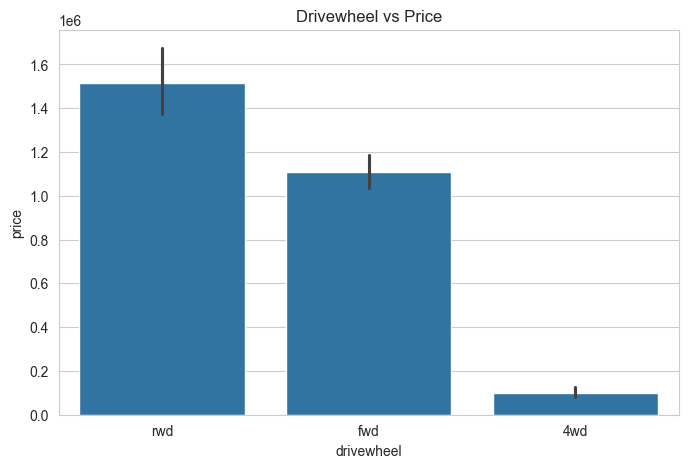

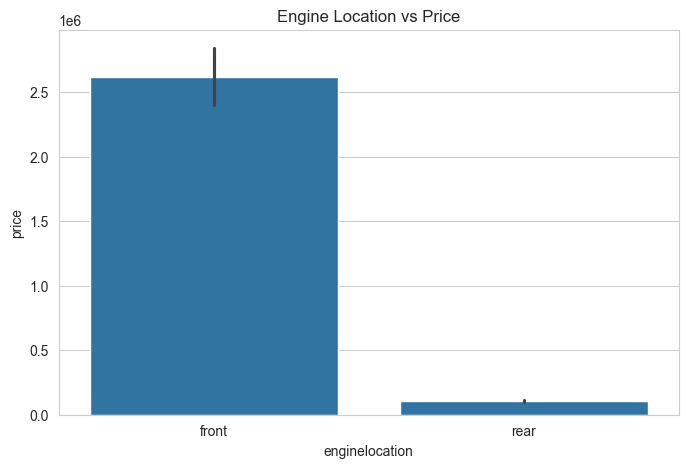

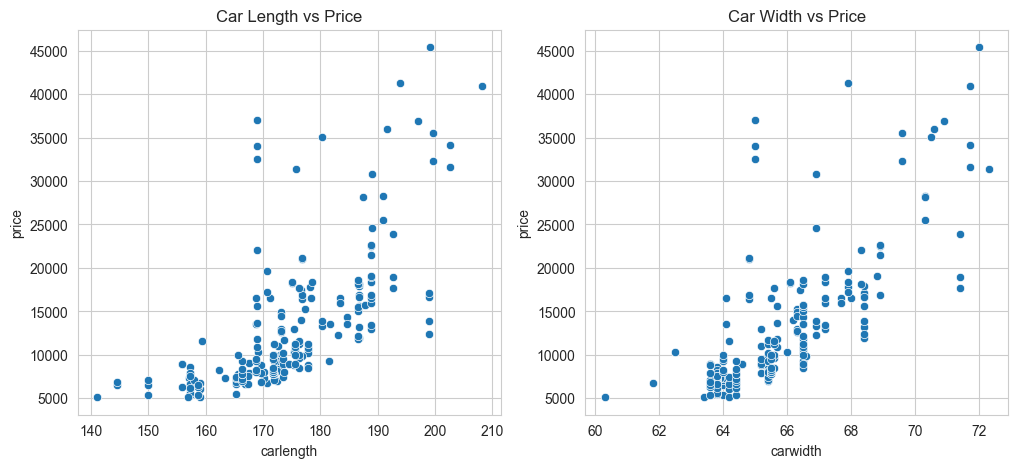

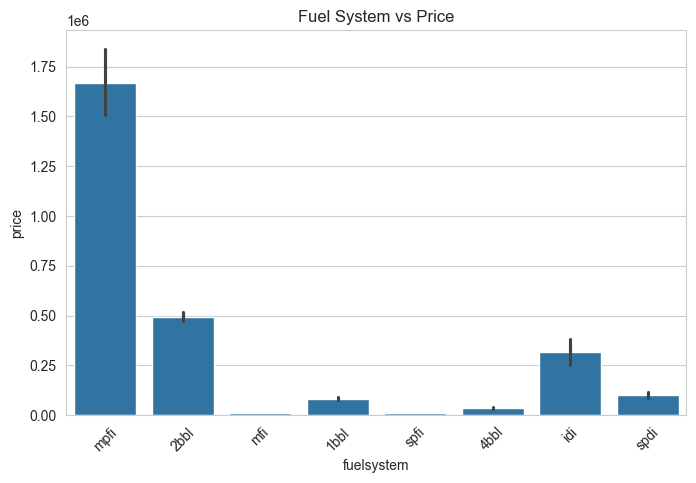

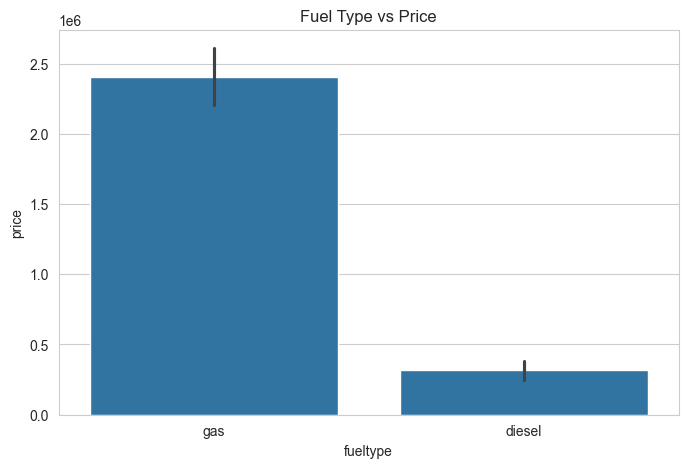

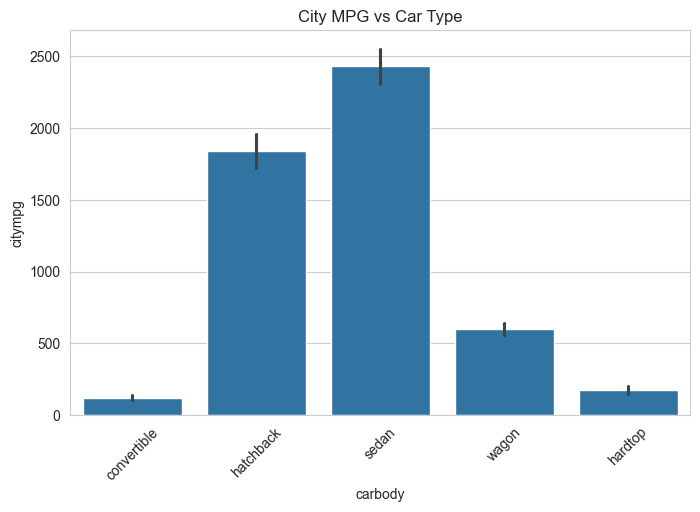

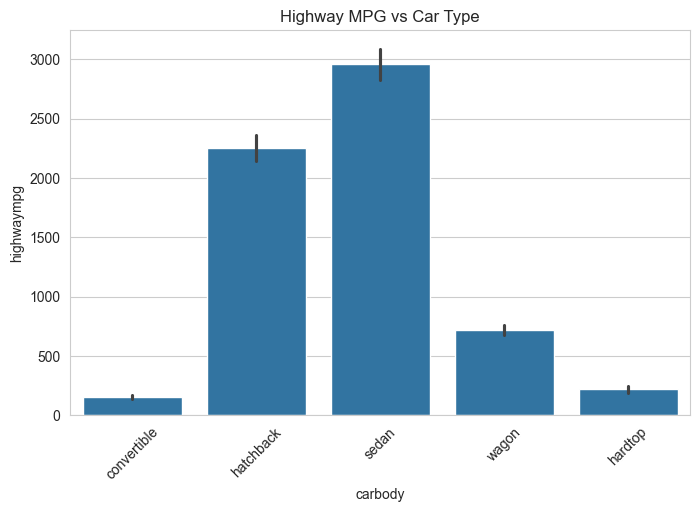

In [20]:
# Set plot style
sns.set_style("whitegrid")

# Compression Ratio vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['compressionratio'], y=df['price'])
plt.title("Compression Ratio vs Price")
plt.xlabel("Compression Ratio")
plt.ylabel("Price")
plt.show()

# Fuel Efficiency vs Performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(ax=axes[0], x=df['citympg'], y=df['price'])
axes[0].set_title("City MPG vs Price")
sns.scatterplot(ax=axes[1], x=df['highwaympg'], y=df['price'])
axes[1].set_title("Highway MPG vs Price")
plt.show()

# Car Body & Price Distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=df['carbody'], y=df['price'], estimator=sum)
plt.title("Car Body Type vs Price")
plt.xticks(rotation=45)
plt.show()

# Drivewheel vs Price
plt.figure(figsize=(8, 5))
sns.barplot(x=df['drivewheel'], y=df['price'], estimator=sum)
plt.title("Drivewheel vs Price")
plt.show()

# Engine Location vs Price
plt.figure(figsize=(8, 5))
sns.barplot(x=df['enginelocation'], y=df['price'], estimator=sum)
plt.title("Engine Location vs Price")
plt.show()

# Car Length & Width vs Price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(ax=axes[0], x=df['carlength'], y=df['price'])
axes[0].set_title("Car Length vs Price")
sns.scatterplot(ax=axes[1], x=df['carwidth'], y=df['price'])
axes[1].set_title("Car Width vs Price")
plt.show()

# Fuel System & Fuel Type Impact on Price
plt.figure(figsize=(8, 5))
sns.barplot(x=df['fuelsystem'], y=df['price'], estimator=sum)
plt.title("Fuel System vs Price")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=df['fueltype'], y=df['price'], estimator=sum)
plt.title("Fuel Type vs Price")
plt.show()

# Fuel Efficiency vs Car Type
plt.figure(figsize=(8, 5))
sns.barplot(x=df['carbody'], y=df['citympg'], estimator=sum)
plt.title("City MPG vs Car Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=df['carbody'], y=df['highwaympg'], estimator=sum)
plt.title("Highway MPG vs Car Type")
plt.xticks(rotation=45)
plt.show()

In [21]:


# Define features and target variable (update column names as needed)
X = df.drop(columns=['price'])  # Assuming 'price' is the target column
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop non-numeric columns from both X_train and X_test
X_train = X_train.select_dtypes(include=[np.number])  # This keeps only numeric columns
X_test = X_test.select_dtypes(include=[np.number])  # This keeps only numeric columns

# Standardizing features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')


MAE: 2411.09
MSE: 11710105.08
RMSE: 3422.00
R² Score: 0.85


In [31]:
# For Ridge Regression: Get coefficients
coefficients = model.coef_
print("Model Coefficients: ", coefficients)

# If using Decision Tree or Random Forest, get feature importance:
if hasattr(model, 'feature_importances_'):
    feature_importances = model.feature_importances_
    print("Feature Importances: ", feature_importances)


Model Coefficients:  [ 2.26486650e+02  1.27888993e+03  9.73233863e+01 -2.46443151e+02
  8.40035706e+02 -4.02452633e+02  1.75440551e+01 -1.08124265e+01
 -4.06532200e+03 -5.82403650e+02 -7.89842409e+02 -1.96326235e+01
  2.48510771e+00  3.96198604e+02 -2.28838018e+02  2.21889782e+04
  1.89715993e+04  2.17501127e+04  2.22510705e+04  2.40269162e+03
  3.69938177e+03  2.92754246e+03  4.58217073e-08  5.77823589e+03
  2.72357951e+04  4.06167940e+04  3.92235476e+04  9.64564606e-08
  6.67878339e-08  3.65579525e+04  6.83266990e-08  4.08413143e-08
  3.91264621e-09  1.57924660e-08  1.67148230e+03  1.46020064e+04
 -3.27798621e+03 -5.14523316e+03  1.99074748e-08  1.29236814e+04
  1.16423568e+04  1.30724869e+04  8.62120044e+03 -7.91351340e-09
  1.02988985e+04  5.52717592e+03  1.33428970e+04  1.43529932e+04
  9.63342888e+03  1.08111944e+04  1.40145389e+04  1.08116971e+04
  1.22556516e+04  1.16770480e+04  6.82799714e+03  1.34796489e+04
  1.35681219e+04  1.12890310e+04  1.22944933e+04  8.32972920e+03
  2.

In [32]:
from sklearn.model_selection import GridSearchCV

# Example: Ridge Regression Hyperparameter tuning
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(estimator=Ridge(), param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

# Train the model with the best parameters
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)


Best Parameters: {'alpha': 1}
Best Score: -7896955.230256787


In [33]:
import joblib

# Save the trained model
joblib.dump(model, 'car_price_predictor.pkl')

# To load the saved model later
model_loaded = joblib.load('car_price_predictor.pkl')


In [36]:
# Example of new car data (e.g., year, make, mileage, fuel type)
new_data = [[2020, 'sedan', 15000, 'gas', 'fwd', 'front', 112, 70, 24, 30, 9.5]  ] 
# Preprocess new data (e.g., encoding, scaling)
# For example, if you've applied OneHotEncoder to categorical columns:
new_data_encoded = encoder.transform(new_data)  # Assuming `encoder` is your trained encoder

# Make prediction
predicted_price = model.predict(new_data_encoded)
print(f"Predicted Car Price: {predicted_price}")


NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [42]:
# Check the columns in X_train to ensure they match the expected structure
print(X_train.columns)


Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       ...
       'cylindernumber_three', 'cylindernumber_twelve', 'cylindernumber_two',
       'fuelsystem_2bbl', 'fuelsystem_4bbl', 'fuelsystem_idi',
       'fuelsystem_mfi', 'fuelsystem_mpfi', 'fuelsystem_spdi',
       'fuelsystem_spfi'],
      dtype='object', length=190)
